<a href="https://colab.research.google.com/github/fealmutairi79-0/CS-220P/blob/main/notebooks/01e-mlp-for-classification-with-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptrons (MLPs) for Classification with PyTorch

In [1]:
import numpy as np
from sklearn import compose, datasets, linear_model, metrics, model_selection
from sklearn import pipeline, preprocessing

import torch
from torch import nn, optim


## Binary Classification

### Loading the data

In [2]:
breast_cancer_dataset = datasets.load_breast_cancer(
    as_frame=True,
)

In [3]:
print(breast_cancer_dataset["DESCR"])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
breast_cancer_features_df = breast_cancer_dataset["data"]
breast_cancer_target = breast_cancer_dataset["target"]

In [5]:
breast_cancer_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
breast_cancer_features_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


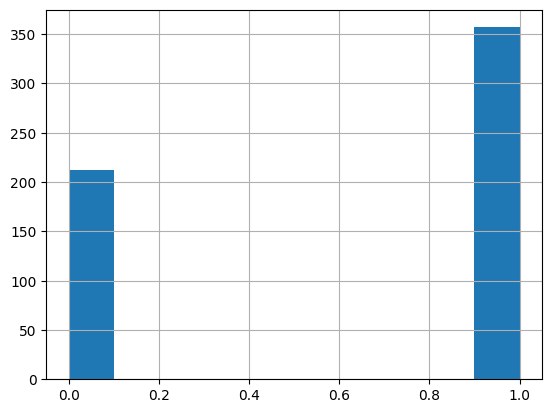

In [7]:
_ = breast_cancer_target.hist()

### Prepare the data

#### Train/Val Split

In [8]:
RANDOM_STATE = np.random.RandomState(42)


train_features_df, val_features_df, train_target, val_target = (
    model_selection.train_test_split(
        breast_cancer_features_df,
        breast_cancer_target,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=breast_cancer_target,
        test_size=0.20,
    )
)


#### Features and target preparation

In [9]:
def array_to_tensor(arr, dtype=torch.float32):
    return torch.tensor(arr, dtype=dtype)


def series_to_tensor(s, dtype=torch.float32):
    arr = s.to_numpy()
    return array_to_tensor(arr, dtype)


n_samples, _ = train_features_df.shape
prepare_breast_cancer_features = pipeline.make_pipeline(
    preprocessing.QuantileTransformer(
      n_quantiles=n_samples,
      output_distribution="normal",
      random_state=RANDOM_STATE
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor
    )
)

prepare_breast_cancer_target = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(
        func=series_to_tensor,
    ),
    preprocessing.FunctionTransformer(
        func=torch.unsqueeze,
        kw_args={
            "dim": 1
        }
    )
)

In [10]:
X_train = prepare_breast_cancer_features.fit_transform(train_features_df)
X_val = prepare_breast_cancer_features.transform(val_features_df)


In [11]:
print(X_train.shape)
print(X_val.shape)

torch.Size([455, 30])
torch.Size([114, 30])


In [12]:
y_train = prepare_breast_cancer_target.fit_transform(train_target)
y_val = prepare_breast_cancer_target.transform(val_target)


In [13]:
print(y_train.shape)
print(y_val.shape)

# for binary classification targets are probs!
print(y_train.dtype)
print(y_val.dtype)

torch.Size([455, 1])
torch.Size([114, 1])
torch.float32
torch.float32


### Implementing an MLP for Binary Classification using nn.Sequential

[`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) in PyTorch is a container module that allows for the sequential execution of a series of neural network layers or modules. It simplifies the process of building neural networks with a linear, feed-forward structure by eliminating the need to explicitly define the forward method for each layer.


### Key Characteristics and Use-Cases

* **Ordered Container:** `nn.Sequential` takes a list of `nn.Module` instances (layers) and arranges them in the order they are provided.
* **Automatic Forward Pass:** When an input tensor is passed to an `nn.Sequential` object, it automatically propagates through each contained module in the defined order, with the output of one module serving as the input to the next.
* **Simplified Model Definition:** It offers a concise way to define models, especially for straightforward architectures without complex branching or custom logic within the forward pass.
* **Treat as a Single Module:** The entire `nn.Sequential` container can be treated as a single `nn.Module`, allowing for easy integration into larger models or for applying operations like moving to a device (`.to(device)`) or setting training/evaluation mode (`.train()`, `.eval()`).

In [14]:
_ = torch.manual_seed(42)#الخطوة ذي تصير فيها اخطاء

n_features = X_train.size(1) #في المشروع المدخلات بتكون ١٠٢٤ و المخرجات عدد الحروف ٢٨
n_outputs = 1


# use the 2/3 heuristic for choosing the number of neurons
n_hidden = (2 * (n_features + n_outputs) ) // 3 #تقدر تحط ارقام مهو شرط معادلة على حسب البيانات عندك


breast_cancer_model = nn.Sequential(#تقدر تغير فيها هنا عشان ترفع الدقة
    nn.Linear(
        in_features=n_features,
        out_features=n_hidden,# الافضل تبدا بشيء صغير مرة ثم تبدأ تزيد
        bias=True,
    ),
    nn.ReLU(),#اي شيء صفر او اصغر من الصفر تخليه صفر
    nn.Linear(
        in_features=n_hidden,
        out_features=n_outputs,
        bias=True,
    ),
)

### Loss functions and optimizers

In [15]:
# bincount only works with 1D tensors of non-negative integers!
n_negative_samples, n_positive_samples = torch.bincount(y_train.squeeze().to(torch.int64))
positive_weight = torch.tensor([n_negative_samples / n_positive_samples], dtype=torch.float32)
print(positive_weight)

tensor([0.5965])


In [16]:
binary_cross_entropy_loss = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

sgd = optim.SGD(
    breast_cancer_model.parameters(),
    lr=1e-2,#تقدر تغير هنا عشان ترفع الدقة
)

In [17]:
def train(
    model_fn,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs,
    log_epochs=1,
    ):

    for epoch in range(n_epochs):
        # enable training mode
        model_fn.train()

        # forward pass
        y_pred = model_fn(X_train)
        train_loss = criterion(y_pred, y_train)

        # backward pass
        train_loss.backward()#ذي ماتتغير

        # gradient descent step
        optimizer.step()
        optimizer.zero_grad()

        # evaluate using the validation data
        with torch.no_grad():
            model_fn.eval()
            y_pred = model_fn(X_val)
            val_loss = criterion(y_pred, y_val)

        if (epoch + 1) % log_epochs == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {train_loss.item(): .4f}, Val Loss: {val_loss.item(): .4f}")


In [18]:
train(
    breast_cancer_model,
    binary_cross_entropy_loss,
    sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs=1000. #تقدر تغير هنا عشان ترفع الدقة
)

Epoch 1/1000, Training Loss:  0.5409, Val Loss:  0.5398
Epoch 2/1000, Training Loss:  0.5391, Val Loss:  0.5382
Epoch 3/1000, Training Loss:  0.5374, Val Loss:  0.5366
Epoch 4/1000, Training Loss:  0.5356, Val Loss:  0.5350
Epoch 5/1000, Training Loss:  0.5339, Val Loss:  0.5335
Epoch 6/1000, Training Loss:  0.5322, Val Loss:  0.5319
Epoch 7/1000, Training Loss:  0.5305, Val Loss:  0.5304
Epoch 8/1000, Training Loss:  0.5289, Val Loss:  0.5288
Epoch 9/1000, Training Loss:  0.5272, Val Loss:  0.5273
Epoch 10/1000, Training Loss:  0.5256, Val Loss:  0.5258
Epoch 11/1000, Training Loss:  0.5240, Val Loss:  0.5244
Epoch 12/1000, Training Loss:  0.5224, Val Loss:  0.5229
Epoch 13/1000, Training Loss:  0.5208, Val Loss:  0.5214
Epoch 14/1000, Training Loss:  0.5192, Val Loss:  0.5200
Epoch 15/1000, Training Loss:  0.5177, Val Loss:  0.5185
Epoch 16/1000, Training Loss:  0.5161, Val Loss:  0.5171
Epoch 17/1000, Training Loss:  0.5146, Val Loss:  0.5157
Epoch 18/1000, Training Loss:  0.5130, V

## Multi-class Classification

### Loading the data

In [19]:
covtype_dataset = datasets.fetch_covtype(
    as_frame=True
)

In [20]:
print(covtype_dataset["DESCR"])

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

In [21]:
covtype_features_df = covtype_dataset["data"]
covtype_target_df = (
    covtype_dataset.get("target")
                   .to_frame()
)

In [22]:
covtype_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

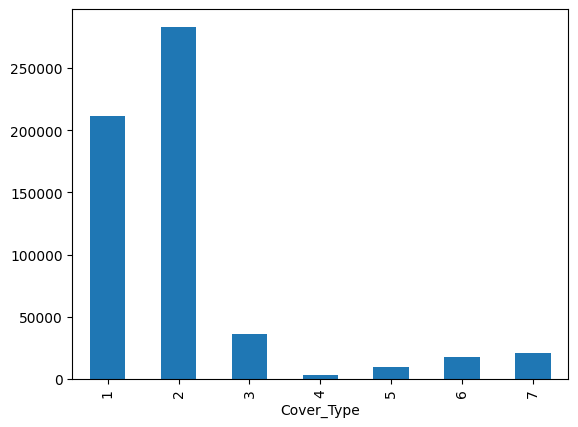

In [23]:
_ = (
    covtype_target_df.loc[:, "Cover_Type"]
                     .value_counts()
                     .sort_index()
                     .plot(kind="bar")
)

### Preparing the data

#### Train/Val Split

In [24]:
train_features_df, val_features_df, train_target_df, val_target_df = (
    model_selection.train_test_split(
        covtype_features_df,
        covtype_target_df,
        test_size=0.20,
        shuffle=True,
        stratify=covtype_target_df,
        random_state=RANDOM_STATE
    )
)


#### Features and target preparation

In [25]:
prepare_covtype_features = pipeline.make_pipeline(
    compose.make_column_transformer(
        (
            "passthrough",
            compose.make_column_selector(
                pattern="^Wilderness_Area_|^Soil_Type_"
            )
        ),
        force_int_remainder_cols=False,
        n_jobs=-1,
        remainder=preprocessing.QuantileTransformer(
            output_distribution="normal",
            random_state=RANDOM_STATE,
        )
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor,
    )
)

prepare_covtype_target = pipeline.make_pipeline(
    preprocessing.OrdinalEncoder(
        categories=[
            [1, 2, 3, 4, 5, 6, 7]
        ],
    ),
    preprocessing.FunctionTransformer(
        func=array_to_tensor,
        kw_args={
            "dtype": torch.int64
        }
    ),
    preprocessing.FunctionTransformer(
        func=torch.squeeze,
    )
)



In [26]:
X_train = prepare_covtype_features.fit_transform(train_features_df)
X_val = prepare_covtype_features.transform(val_features_df)


In [27]:
print(X_train.shape)
print(X_val.shape)

torch.Size([464809, 54])
torch.Size([116203, 54])


In [28]:
y_train = prepare_covtype_target.fit_transform(train_target_df)
y_val = prepare_covtype_target.transform(val_target_df)


In [29]:
# again note that the targets are 1-dimensional!
print(y_train.shape)
print(y_train.dtype)

print(y_val.shape)
print(y_val.dtype)

torch.Size([464809])
torch.int64
torch.Size([116203])
torch.int64


### Exercise:

Implement a MLP using `nn.Sequential` that has three hidden layers with sizes 200, 100, and 50. Use `nn.ReLU` activation functions.

In [30]:
# INSERT YOUR CODE HERE!

### Solution:

In [31]:
_ = torch.manual_seed(42)

n_features = X_train.size(1)
n_classes = y_train.unique().size(0)

covtype_model = nn.Sequential(
    nn.Linear(
        in_features=n_features,
        out_features=200,
        bias=True,
    ),
    nn.ReLU(),
    nn.Linear(
        in_features=200,
        out_features=100,
        bias=True,
    ),
    nn.ReLU(),
    nn.Linear(
        in_features=100,
        out_features=50,
        bias=True,
    ),
    nn.ReLU(),
    nn.Linear(
        in_features=50,
        out_features=n_classes,
        bias=True,
    ),
)


### Exercise:

Train your MLP for 100 epochs to minimize `nn.CrossEntropyLoss` using plain vanilla `optim.SGD` with a learning rate of 1.

In [32]:
# INSERT YOUR CODE HERE!

### Solution:

In [33]:
# rare classes get larger weight when calculating the loss
n_samples = y_train.size(0)
weights = n_samples / (n_classes * torch.bincount(y_train))
normalized_weights = weights / weights.sum()

cross_entropy_loss = nn.CrossEntropyLoss(
    weight=normalized_weights
)

sgd = optim.SGD(
    covtype_model.parameters(),
    lr=1e0
)

In [34]:
train(
    covtype_model,
    cross_entropy_loss,
    sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs=100,
    log_epochs=1,
)

Epoch 1/100, Training Loss:  1.9530, Val Loss:  1.9379
Epoch 2/100, Training Loss:  1.9378, Val Loss:  1.9225
Epoch 3/100, Training Loss:  1.9221, Val Loss:  1.9030
Epoch 4/100, Training Loss:  1.9023, Val Loss:  1.8740
Epoch 5/100, Training Loss:  1.8727, Val Loss:  1.8277
Epoch 6/100, Training Loss:  1.8258, Val Loss:  1.7594
Epoch 7/100, Training Loss:  1.7566, Val Loss:  1.6760
Epoch 8/100, Training Loss:  1.6725, Val Loss:  1.5847
Epoch 9/100, Training Loss:  1.5810, Val Loss:  1.4888
Epoch 10/100, Training Loss:  1.4850, Val Loss:  1.3998
Epoch 11/100, Training Loss:  1.3958, Val Loss:  1.4672
Epoch 12/100, Training Loss:  1.4642, Val Loss:  2.1521
Epoch 13/100, Training Loss:  2.1485, Val Loss:  2.1332
Epoch 14/100, Training Loss:  2.1292, Val Loss:  1.8180
Epoch 15/100, Training Loss:  1.8184, Val Loss:  1.7265
Epoch 16/100, Training Loss:  1.7267, Val Loss:  1.6457
Epoch 17/100, Training Loss:  1.6458, Val Loss:  1.5666
Epoch 18/100, Training Loss:  1.5664, Val Loss:  1.4806
E